# Ridge Model 2 - Extended Dynamic

This notebook trains and evaluates Ridge Regression for main GDP Model 2.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

BASE_DIR = Path("/Users/tonytony/Final Project")
DATA_PATH = BASE_DIR / "Data" / "Cleaned" / "panel_with_event_dummies_and_extra_drivers.csv"
OUTPUT_DIR = BASE_DIR / "Data" / "Cleaned"

TRAIN_END_YEAR = 2017
VALID_START_YEAR = 2016
TEST_START_YEAR = 2018
TEST_END_YEAR = 2022

TARGET_COL = "target_log_gdp_next_year"
MODEL_NAME = "Ridge Model 2 - Extended Dynamic"
MODEL_FAMILY = "Regularized Linear ML"
MODEL_NOTE = "Ridge version of Model 2 using lag GDP, population, life expectancy, inflation, unemployment, and internet usage."
OUTPUT_PREFIX = "gdp_ridge_model_2_dynamic"

ALPHA_GRID = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

USECOLS = [
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "target_log_gdp_next_year",
]
NUMERIC_FEATURES = [
    "log_gdp_per_capita",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
]
CATEGORICAL_FEATURES = []
MAKE_YEAR_TREND = False

print("Base dir:", BASE_DIR)
print("Data path:", DATA_PATH)
print("Output dir:", OUTPUT_DIR)
print("Model:", MODEL_NAME)

Base dir: /Users/tonytony/Final Project
Data path: /Users/tonytony/Final Project/Data/Cleaned/panel_with_event_dummies_and_extra_drivers.csv
Output dir: /Users/tonytony/Final Project/Data/Cleaned
Model: Ridge Model 2 - Extended Dynamic


In [2]:
def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))

    nonzero_mask = actual != 0
    if nonzero_mask.any():
        mape = np.mean(
            np.abs((actual[nonzero_mask] - predicted[nonzero_mask]) / actual[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    sst = np.sum((actual - actual.mean()) ** 2)
    sse = np.sum((actual - predicted) ** 2)
    r2 = 1 - (sse / sst) if sst > 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2,
    }


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def sanitize_feature_name(name):
    name = str(name)
    name = name.replace("num__", "")
    name = name.replace("cat__", "")
    return name


def build_pipeline(numeric_features, categorical_features, alpha):
    transformers = []

    if numeric_features:
        transformers.append(("num", StandardScaler(), numeric_features))

    if categorical_features:
        transformers.append(("cat", make_one_hot_encoder(), categorical_features))

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

    model = Ridge(alpha=alpha, fit_intercept=True)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    return pipeline


def build_prediction_frame(pipeline, df, model_name, model_family, model_note, alpha):
    pred_df = df.copy()

    pred_df["model"] = model_name
    pred_df["model_family"] = model_family
    pred_df["model_note"] = model_note
    pred_df["alpha"] = alpha

    pred_df["predicted_log_gdp_next_year"] = pipeline.predict(pred_df)
    pred_df["actual_log_gdp_next_year"] = pred_df[TARGET_COL]

    pred_df["predicted_gdp_next_year"] = np.exp(pred_df["predicted_log_gdp_next_year"])
    pred_df["actual_gdp_next_year"] = np.exp(pred_df["actual_log_gdp_next_year"])

    pred_df["feature_year"] = pred_df["year"].astype(int)
    pred_df["target_year"] = pred_df["feature_year"] + 1

    pred_df["absolute_error_usd"] = np.abs(
        pred_df["actual_gdp_next_year"] - pred_df["predicted_gdp_next_year"]
    )
    pred_df["absolute_percentage_error_pct"] = (
        pred_df["absolute_error_usd"] / pred_df["actual_gdp_next_year"]
    ) * 100
    pred_df["signed_percentage_error_pct"] = (
        (pred_df["predicted_gdp_next_year"] - pred_df["actual_gdp_next_year"])
        / pred_df["actual_gdp_next_year"]
    ) * 100

    return pred_df


def build_yearly_summary(pred_df):
    rows = []
    for target_year, year_df in pred_df.groupby("target_year"):
        rows.append(
            {
                "target_year": int(target_year),
                "n_obs": len(year_df),
                "actual_mean_gdp": year_df["actual_gdp_next_year"].mean(),
                "predicted_mean_gdp": year_df["predicted_gdp_next_year"].mean(),
                "pred_to_actual_ratio": (
                    year_df["predicted_gdp_next_year"].mean()
                    / year_df["actual_gdp_next_year"].mean()
                ),
                "mean_absolute_percentage_error_pct": year_df[
                    "absolute_percentage_error_pct"
                ].mean(),
            }
        )
    return pd.DataFrame(rows).sort_values("target_year").reset_index(drop=True)


def build_region_metrics(pred_df):
    rows = []
    for region_name, region_df in pred_df.groupby("wb_region"):
        rows.append(
            {
                "wb_region": region_name,
                "n_obs": len(region_df),
                **regression_metrics(
                    actual=region_df["actual_gdp_next_year"],
                    predicted=region_df["predicted_gdp_next_year"],
                ),
            }
        )
    return pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)


def coefficient_table(pipeline):
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    feature_names = [sanitize_feature_name(x) for x in feature_names]

    coefficients = pipeline.named_steps["model"].coef_

    coef_df = pd.DataFrame(
        {
            "term": feature_names,
            "coefficient": coefficients,
            "abs_coefficient": np.abs(coefficients),
        }
    ).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

    return coef_df


def show_or_close_plot():
    if "ipykernel" in sys.modules:
        plt.show()
    else:
        plt.close()

Sample shape: (4722, 13)
Train core rows: 3570
Validation rows: 339
Train full rows: 3909
Test rows: 813
Test target years: 2019 - 2023
Best alpha: 10.0


,model,alpha,n_valid,valid_MAE_level,valid_RMSE_level,valid_MAPE_level,valid_R2_level,valid_MAE_log,valid_RMSE_log,valid_MAPE_log,valid_R2_log
0,Ridge Model 2 - Extended Dynamic,10.0000,339,827.9908,"1,660.6543",5.7934,0.9936,0.0589,0.0927,0.6993,0.9958
1,Ridge Model 2 - Extended Dynamic,5.0000,339,838.4490,"1,661.4553",5.8545,0.9936,0.0596,0.0930,0.7065,0.9958
2,Ridge Model 2 - Extended Dynamic,1.0000,339,847.3543,"1,663.1239",5.9117,0.9935,0.0603,0.0933,0.7135,0.9957
3,Ridge Model 2 - Extended Dynamic,0.5000,339,848.4892,"1,663.3983",5.9191,0.9935,0.0604,0.0934,0.7144,0.9957
4,Ridge Model 2 - Extended Dynamic,0.1000,339,849.3992,"1,663.6284",5.9250,0.9935,0.0605,0.0934,0.7151,0.9957
5,Ridge Model 2 - Extended Dynamic,0.0500,339,849.5130,"1,663.6578",5.9258,0.9935,0.0605,0.0934,0.7152,0.9957
6,Ridge Model 2 - Extended Dynamic,0.0100,339,849.6042,"1,663.6815",5.9264,0.9935,0.0605,0.0934,0.7153,0.9957
7,Ridge Model 2 - Extended Dynamic,0.0050,339,849.6155,"1,663.6845",5.9265,0.9935,0.0605,0.0934,0.7153,0.9957
8,Ridge Model 2 - Extended Dynamic,0.0010,339,849.6247,"1,663.6868",5.9265,0.9935,0.0605,0.0934,0.7153,0.9957
9,Ridge Model 2 - Extended Dynamic,0.0005,339,849.6258,"1,663.6871",5.9265,0.9935,0.0605,0.0934,0.7153,0.9957


,model,model_family,split,scale,n_obs,alpha,MAE,RMSE,MAPE_pct,R_squared
0,Ridge Model 2 - Extended Dynamic,Regularized Linear ML,train,level_gdp_usd,3909,10.0000,941.9662,"2,176.0164",9.0280,0.9841
1,Ridge Model 2 - Extended Dynamic,Regularized Linear ML,train,log_gdp,3909,10.0000,0.0887,0.1305,1.1243,0.9930
2,Ridge Model 2 - Extended Dynamic,Regularized Linear ML,test,level_gdp_usd,813,10.0000,"1,490.5958","3,483.9800",9.1480,0.9765
3,Ridge Model 2 - Extended Dynamic,Regularized Linear ML,test,log_gdp,813,10.0000,0.0894,0.1238,1.0292,0.9923


,term,coefficient,abs_coefficient
0,log_gdp_per_capita,1.5251,1.5251
1,life_expectancy_years,0.0321,0.0321
2,inflation_pct_clean,0.0044,0.0044
3,log_population_total,-0.0043,0.0043
4,internet_users_pct_clean,-0.0015,0.0015
5,unemployment_pct_clean,0.0005,0.0005


,target_year,n_obs,actual_mean_gdp,predicted_mean_gdp,pred_to_actual_ratio,mean_absolute_percentage_error_pct
0,2019,166,"15,698.9605","16,338.1751",1.0407,5.9048
1,2020,166,"14,549.3612","16,126.2069",1.1084,13.8602
2,2021,162,"17,155.0981","15,143.8522",0.8828,9.9304
3,2022,160,"18,048.6179","17,697.0653",0.9805,8.2090
4,2023,159,"18,914.0876","18,534.9312",0.9800,7.7620


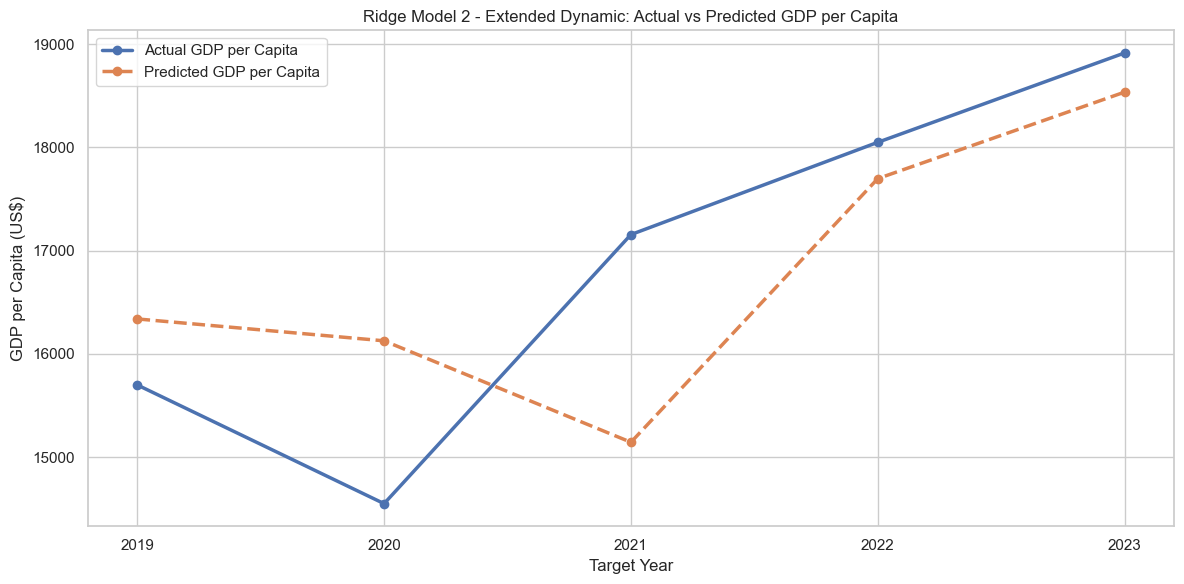

Saved:
- /Users/tonytony/Final Project/Data/Cleaned/gdp_ridge_model_2_dynamic_validation_search.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_ridge_model_2_dynamic_metrics.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_ridge_model_2_dynamic_train_predictions.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_ridge_model_2_dynamic_test_predictions.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_ridge_model_2_dynamic_yearly_summary.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_ridge_model_2_dynamic_coefficients.csv
- /Users/tonytony/Final Project/Data/Cleaned/gdp_ridge_model_2_dynamic_region_metrics.csv


In [3]:
meta_cols = [
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "gdp_per_capita_usd",
    TARGET_COL,
]

all_usecols = list(dict.fromkeys(meta_cols + USECOLS))
panel_df = pd.read_csv(DATA_PATH, usecols=all_usecols)
model_df = panel_df.copy()

for col in all_usecols:
    if col not in ["country_name", "country_code", "wb_region"]:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna().copy()
model_df["country_name"] = model_df["country_name"].astype(str)
model_df["country_code"] = model_df["country_code"].astype(str)
model_df["wb_region"] = model_df["wb_region"].astype(str)
model_df["year"] = model_df["year"].astype(int)

if MAKE_YEAR_TREND:
    model_df["year_trend"] = model_df["year"] - model_df["year"].min()

FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
model_df = model_df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()

train_full_df = model_df[model_df["year"] <= TRAIN_END_YEAR].copy()
train_core_df = model_df[model_df["year"] < VALID_START_YEAR].copy()
valid_df = model_df[
    (model_df["year"] >= VALID_START_YEAR) & (model_df["year"] <= TRAIN_END_YEAR)
].copy()
test_df = model_df[
    (model_df["year"] >= TEST_START_YEAR) & (model_df["year"] <= TEST_END_YEAR)
].copy()

print("Sample shape:", model_df.shape)
print("Train core rows:", len(train_core_df))
print("Validation rows:", len(valid_df))
print("Train full rows:", len(train_full_df))
print("Test rows:", len(test_df))
print(
    "Test target years:",
    int((test_df["year"] + 1).min()),
    "-",
    int((test_df["year"] + 1).max()),
)

validation_rows = []
for alpha in ALPHA_GRID:
    pipeline = build_pipeline(
        numeric_features=NUMERIC_FEATURES,
        categorical_features=CATEGORICAL_FEATURES,
        alpha=alpha,
    )
    pipeline.fit(train_core_df[FEATURE_COLS], train_core_df[TARGET_COL])

    valid_pred_log = pipeline.predict(valid_df[FEATURE_COLS])
    valid_actual_log = valid_df[TARGET_COL].to_numpy()

    valid_pred_level = np.exp(valid_pred_log)
    valid_actual_level = np.exp(valid_actual_log)

    level_metrics = regression_metrics(
        actual=valid_actual_level,
        predicted=valid_pred_level,
    )
    log_metrics = regression_metrics(
        actual=valid_actual_log,
        predicted=valid_pred_log,
    )

    validation_rows.append(
        {
            "model": MODEL_NAME,
            "alpha": alpha,
            "n_valid": len(valid_df),
            "valid_MAE_level": level_metrics["MAE"],
            "valid_RMSE_level": level_metrics["RMSE"],
            "valid_MAPE_level": level_metrics["MAPE_pct"],
            "valid_R2_level": level_metrics["R_squared"],
            "valid_MAE_log": log_metrics["MAE"],
            "valid_RMSE_log": log_metrics["RMSE"],
            "valid_MAPE_log": log_metrics["MAPE_pct"],
            "valid_R2_log": log_metrics["R_squared"],
        }
    )

validation_df = pd.DataFrame(validation_rows).sort_values(
    ["valid_RMSE_level", "valid_MAPE_level", "valid_MAE_level"]
).reset_index(drop=True)

best_row = validation_df.iloc[0]
best_alpha = float(best_row["alpha"])

print("Best alpha:", best_alpha)
display(validation_df.head(10))

final_pipeline = build_pipeline(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    alpha=best_alpha,
)
final_pipeline.fit(train_full_df[FEATURE_COLS], train_full_df[TARGET_COL])

train_pred_df = build_prediction_frame(
    pipeline=final_pipeline,
    df=train_full_df,
    model_name=MODEL_NAME,
    model_family=MODEL_FAMILY,
    model_note=MODEL_NOTE,
    alpha=best_alpha,
)

test_pred_df = build_prediction_frame(
    pipeline=final_pipeline,
    df=test_df,
    model_name=MODEL_NAME,
    model_family=MODEL_FAMILY,
    model_note=MODEL_NOTE,
    alpha=best_alpha,
)

metrics_df = pd.DataFrame(
    [
        {
            "model": MODEL_NAME,
            "model_family": MODEL_FAMILY,
            "split": "train",
            "scale": "level_gdp_usd",
            "n_obs": len(train_pred_df),
            "alpha": best_alpha,
            **regression_metrics(
                actual=train_pred_df["actual_gdp_next_year"],
                predicted=train_pred_df["predicted_gdp_next_year"],
            ),
        },
        {
            "model": MODEL_NAME,
            "model_family": MODEL_FAMILY,
            "split": "train",
            "scale": "log_gdp",
            "n_obs": len(train_pred_df),
            "alpha": best_alpha,
            **regression_metrics(
                actual=train_pred_df["actual_log_gdp_next_year"],
                predicted=train_pred_df["predicted_log_gdp_next_year"],
            ),
        },
        {
            "model": MODEL_NAME,
            "model_family": MODEL_FAMILY,
            "split": "test",
            "scale": "level_gdp_usd",
            "n_obs": len(test_pred_df),
            "alpha": best_alpha,
            **regression_metrics(
                actual=test_pred_df["actual_gdp_next_year"],
                predicted=test_pred_df["predicted_gdp_next_year"],
            ),
        },
        {
            "model": MODEL_NAME,
            "model_family": MODEL_FAMILY,
            "split": "test",
            "scale": "log_gdp",
            "n_obs": len(test_pred_df),
            "alpha": best_alpha,
            **regression_metrics(
                actual=test_pred_df["actual_log_gdp_next_year"],
                predicted=test_pred_df["predicted_log_gdp_next_year"],
            ),
        },
    ]
).round(4)

coef_df = coefficient_table(final_pipeline).round(6)
yearly_summary_df = build_yearly_summary(test_pred_df).round(4)
region_metrics_df = build_region_metrics(test_pred_df).round(4)

display(metrics_df)
display(coef_df.head(20))
display(yearly_summary_df)

plt.plot(
    yearly_summary_df["target_year"],
    yearly_summary_df["actual_mean_gdp"],
    marker="o",
    linewidth=2.5,
    label="Actual GDP per Capita",
)
plt.plot(
    yearly_summary_df["target_year"],
    yearly_summary_df["predicted_mean_gdp"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="Predicted GDP per Capita",
)
plt.title(f"{MODEL_NAME}: Actual vs Predicted GDP per Capita")
plt.xlabel("Target Year")
plt.ylabel("GDP per Capita (US$)")
plt.xticks(yearly_summary_df["target_year"].astype(int))
plt.legend()
plt.tight_layout()
show_or_close_plot()

validation_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_validation_search.csv"
metrics_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_metrics.csv"
train_pred_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_train_predictions.csv"
test_pred_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_test_predictions.csv"
yearly_summary_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_yearly_summary.csv"
coef_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_coefficients.csv"
region_metrics_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_region_metrics.csv"

validation_df.to_csv(validation_path, index=False)
metrics_df.to_csv(metrics_path, index=False)
train_pred_df.to_csv(train_pred_path, index=False)
test_pred_df.to_csv(test_pred_path, index=False)
yearly_summary_df.to_csv(yearly_summary_path, index=False)
coef_df.to_csv(coef_path, index=False)
region_metrics_df.to_csv(region_metrics_path, index=False)

print("Saved:")
print("-", validation_path)
print("-", metrics_path)
print("-", train_pred_path)
print("-", test_pred_path)
print("-", yearly_summary_path)
print("-", coef_path)
print("-", region_metrics_path)